Notebok - **regresja logistyczna** - klasyfikitor nowotworu piersi.

In [4]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
    )
pd.set_option("display.max_columns",10)

In [6]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target,name="target")

print(f"Rozmiar X: {X.shape}")
print(f"Rozmiar y: {y.shape}")
print(y.value_counts())

X.head()

Rozmiar X: (569, 30)
Rozmiar y: (569,)
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,...,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,...,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,...,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,...,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,...,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,...,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [8]:
#standaryzacja
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#

In [9]:
#budowa modelu
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [10]:
#ocena modelu
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macierz pomyłek:\n{confusion_matrix(y_test, y_pred)}")
print(f"Raport klasyfikacji:\n{classification_report(y_test, y_pred,target_names=data.target_names)}")



Accuracy: 0.9860
Macierz pomyłek:
[[52  1]
 [ 1 89]]
Raport klasyfikacji:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



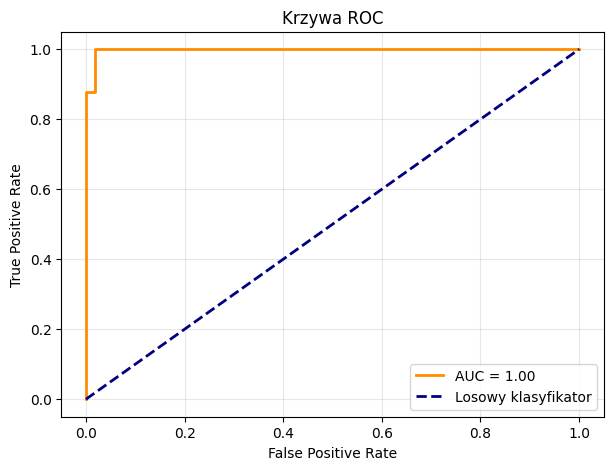

In [12]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,color="darkorange",lw=2,label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--",color="navy",lw=2,label="Losowy klasyfikator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [15]:
#które cechy są najważniejsze?
coef_df = pd.DataFrame({
    "cecha":X.columns,
    "wspolczynnik":model.coef_[0]
})
coef_df["abs_wspolczynnik"] = coef_df["wspolczynnik"].abs()

coef_df.sort_values(
    "abs_wspolczynnik",
    ascending=False
).head(12)

,cecha,wspolczynnik,abs_wspolczynnik
21,worst texture,-1.250149,1.250149
10,radius error,-1.070102,1.070102
28,worst symmetry,-0.957045,0.957045
27,worst concave points,-0.941888,0.941888
13,area error,-0.941059,0.941059
23,worst area,-0.925812,0.925812
20,worst radius,-0.917480,0.917480
26,worst concavity,-0.796758,0.796758
22,worst perimeter,-0.721168,0.721168
5,mean compactness,0.694230,0.694230
